# 🧹 Tahap 3: Data Preparation
**Proyek:** Analisis Sentimen Produk Bummitanni (Tepung Ketan Hitam) — Shopee  
**Metodologi:** CRISP-DM  
**Tahap:** 3 dari 6 — Data Preparation

---
Tujuan tahap ini:
- Membersihkan data dari noise, duplikat, dan anomali
- Melakukan pelabelan sentimen
- Melakukan text preprocessing (lowercase, hapus tanda baca, stopword removal, stemming)
- Menghasilkan dataset bersih siap untuk pemodelan

## Import Library

In [13]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import warnings
import os

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
os.makedirs('output_preparation', exist_ok=True)
print('✅ Library berhasil diimpor!')

✅ Library berhasil diimpor!


## Load Dataset Mentah

In [14]:
df = pd.read_csv('../2-Data-Understanding/ulasan.csv')
print(f'Dataset dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Dataset dimuat: 499 baris x 6 kolom


,No,Username,Rating,Waktu,Ulasan Text,Variasi
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,-
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,-
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,-
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,-
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualita...,-


## Pembersihan Data (Data Cleaning)
### Hapus Duplikat

In [5]:
sebelum = len(df)
df = df.drop_duplicates(subset='Ulasan Text', keep='first').reset_index(drop=True)
sesudah = len(df)
print(f'Sebelum: {sebelum} baris → Sesudah: {sesudah} baris | Terhapus: {sebelum - sesudah} duplikat')

Sebelum: 499 baris → Sesudah: 493 baris | Terhapus: 6 duplikat


### Hapus Noise Nomor Halaman Scraper

In [6]:
def bersihkan_noise_halaman(teks):
    """Hapus pola nomor halaman Shopee sisa scraping, e.g. '0:05 1 2 ... 5 6 7'"""
    # Hapus pola waktu durasi (0:04, 0:18, 1:00, dst)
    teks = re.sub(r'\b\d+:\d{2}\b', '', teks)
    # Hapus pola nomor halaman (1 2 ... 5 6)
    teks = re.sub(r'\b\d+\s+(\d+\s+)*\.\.\.\s+(\d+\s*)+', '', teks)
    # Hapus angka tunggal di akhir kalimat
    teks = re.sub(r'\s+\d+\s*$', '', teks.strip())
    return teks.strip()

df['Ulasan Text'] = df['Ulasan Text'].astype(str).apply(bersihkan_noise_halaman)
print('✅ Noise nomor halaman berhasil dibersihkan')
df[['Username','Ulasan Text']].head(5)

✅ Noise nomor halaman berhasil dibersihkan


,Username,Ulasan Text
0,t*****a,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...
1,t*****9,Jenis: tepung ketan hitam Harga: murah Kualita...
2,a*****2,Rasa: enak Tekstur: normal seperti tepung keta...
3,nienieng,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...
4,Langganan,Jenis: tepung ketan hitam Harga: murah Kualita...


### 3.3 Hapus Ulasan Terlalu Pendek

In [7]:
sebelum = len(df)
df = df[df['Ulasan Text'].astype(str).str.len() >= 10].reset_index(drop=True)
print(f'Terhapus {sebelum - len(df)} ulasan terlalu pendek | Sisa: {len(df)} baris')

Terhapus 9 ulasan terlalu pendek | Sisa: 484 baris


## 🏷️ 4. Pelabelan Sentimen (Sentiment Labeling)
> Karena 99.8% rating = 5, pelabelan menggunakan **kombinasi rating + kata kunci teks**

Distribusi Label Sentimen:
  Positif   :  388 ulasan (80.2%)
  Netral    :   77 ulasan (15.9%)
  Negatif   :   19 ulasan (3.9%)


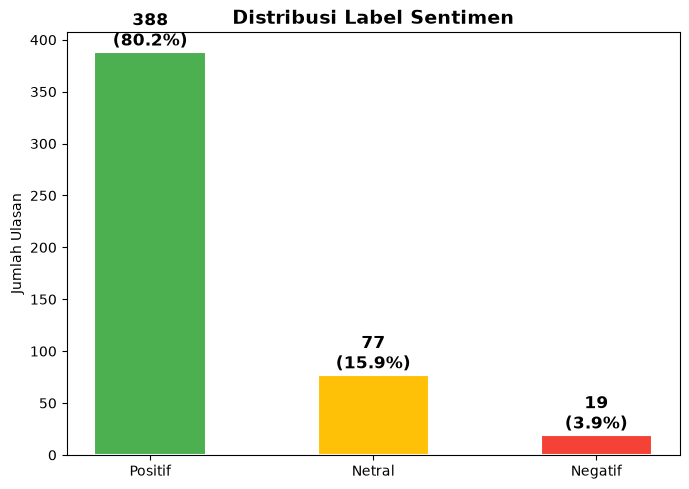

In [8]:
# Daftar kata kunci sentimen
kata_negatif = [
    'kecewa','rusak','bocor','jelek','buruk','tidak bagus','tidak enak',
    'tidak sesuai','mengecewakan','cacat','hancur','bau','apek','tengik',
    'berpasir','kasar','pahit','keras','tidak lembut','tidak halus',
    'kurang','lambat','lama','mahal','penipuan','bohong','palsu'
]
kata_positif = [
    'enak','bagus','lembut','halus','mantap','recommended','rekomendasi',
    'puas','memuaskan','suka','senang','gercep','cepat','amanah','terbaik',
    'laris','langganan','repeat','hitam pekat','wangi','legit','empuk'
]

def label_sentimen(row):
    teks = str(row['Ulasan Text']).lower()
    rating = int(row['Rating'])
    
    ada_negatif = any(k in teks for k in kata_negatif)
    ada_positif = any(k in teks for k in kata_positif)
    
    if rating <= 2 or (rating == 3 and ada_negatif):
        return 'Negatif'
    elif ada_negatif and not ada_positif:
        return 'Negatif'
    elif ada_negatif and ada_positif:
        return 'Netral'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df['Sentimen'] = df.apply(label_sentimen, axis=1)

# Tampilkan distribusi label
label_dist = df['Sentimen'].value_counts()
print('Distribusi Label Sentimen:')
for label, count in label_dist.items():
    print(f'  {label:<10}: {count:>4} ulasan ({count/len(df)*100:.1f}%)')

# Visualisasi
colors = {'Positif': '#4CAF50', 'Netral': '#FFC107', 'Negatif': '#F44336'}
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(label_dist.index, label_dist.values,
              color=[colors.get(l,'gray') for l in label_dist.index],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, label_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.savefig('output_preparation/1-distribusi-sentimen.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## ✏️ 5. Text Preprocessing
### 5.1 Inisialisasi Stemmer & Stopword Remover

In [9]:
factory_stemmer  = StemmerFactory()
factory_stopword = StopWordRemoverFactory()

stemmer          = factory_stemmer.create_stemmer()
stopword_remover = factory_stopword.create_stop_word_remover()

print('✅ Stemmer & StopWordRemover siap!')

✅ Stemmer & StopWordRemover siap!


### 5.2 Fungsi Preprocessing Pipeline

In [10]:
def preprocess(teks):
    """Pipeline preprocessing teks ulasan Bahasa Indonesia."""
    # 1. Lowercase
    teks = teks.lower()
    # 2. Hapus URL
    teks = re.sub(r'http\S+|www\S+', '', teks)
    # 3. Hapus tanda baca & karakter khusus
    teks = re.sub(r'[^\w\s]', ' ', teks)
    # 4. Hapus angka
    teks = re.sub(r'\d+', '', teks)
    # 5. Hapus spasi berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()
    # 6. Stopword removal
    teks = stopword_remover.remove(teks)
    # 7. Stemming
    teks = stemmer.stem(teks)
    return teks

# Contoh preprocessing
contoh = "Kualitas: sangat baik sekali, enak poll dan bakal langganan terus ditoko ini 😍"
print('Sebelum :', contoh)
print('Sesudah :', preprocess(contoh))

Sebelum : Kualitas: sangat baik sekali, enak poll dan bakal langganan terus ditoko ini 😍
Sesudah : kualitas poll langgan toko


### 5.3 Terapkan Preprocessing ke Seluruh Dataset

In [11]:
print('⏳ Memproses teks... (mungkin butuh 1-2 menit)')
df['Teks_Clean'] = df['Ulasan Text'].astype(str).apply(preprocess)
print(f'✅ Preprocessing selesai! {len(df)} ulasan diproses.')

# Tampilkan perbandingan
df[['Ulasan Text','Teks_Clean','Sentimen']].head(10)

⏳ Memproses teks... (mungkin butuh 1-2 menit)
✅ Preprocessing selesai! 484 ulasan diproses.


,Ulasan Text,Teks_Clean,Sentimen
0,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,kualitas bagus cocok boluu nyampenya cepet eks...,Positif
1,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
2,Rasa: enak Tekstur: normal seperti tepung keta...,tekstur normal tepung ketan guna cocok kue sol...,Positif
3,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,bolu guna bolu ketan hitam ori keju lumer kual...,Positif
4,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
5,"Kualitas: sangat baikkk sekali, enak poll dan ...",kualitas baikkk poll langgan toko cocok bolu k...,Positif
6,Jenis: Tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
7,Rasa: enak banget Tekstur: lembut Kegunaan: co...,banget tekstur lembut guna cocok kue tepung as...,Positif
8,Sudah dicoba buat bikin bolu ketan hitam dan e...,coba bikin bolu ketan hitam legit terima kasih...,Positif
9,"Komposisinya 100% beras ketan hitam,alami dan ...",komposisi beras ketan hitam alami produksi lok...,Positif


## 💾 6. Simpan Dataset Bersih

In [12]:
df_clean = df[['No','Username','Rating','Waktu','Ulasan Text','Teks_Clean','Sentimen']].copy()
df_clean = df_clean.reset_index(drop=True)
df_clean['No'] = df_clean.index + 1

df_clean.to_csv('output_preparation/ulasan_clean.csv', index=False)
print(f'✅ Dataset bersih disimpan ke: output_preparation/ulasan_clean.csv')
print(f'   Total baris: {len(df_clean)}')
print()
print('✅ Tahap 3: Data Preparation — SELESAI')
print('   Lanjut → Tahap 4: Modeling')
df_clean.head()

✅ Dataset bersih disimpan ke: output_preparation/ulasan_clean.csv
   Total baris: 484

✅ Tahap 3: Data Preparation — SELESAI
   Lanjut → Tahap 4: Modeling


,No,Username,Rating,Waktu,Ulasan Text,Teks_Clean,Sentimen
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,kualitas bagus cocok boluu nyampenya cepet eks...,Positif
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,tekstur normal tepung ketan guna cocok kue sol...,Positif
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,bolu guna bolu ketan hitam ori keju lumer kual...,Positif
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualita...,jenis tepung ketan hitam harga murah kualitas ...,Positif
